In [55]:
 %matplotlib inline
import matplotlib.pyplot as plt
import seaborn
 plt.style.use('seaborn')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'
import warnings; warnings.simplefilter('ignore')       #忽略警告信息；

In [56]:
import pandas as pd
import numpy as np

In [57]:
import baostock as bs
lg = bs.login()

login success!


In [58]:
rs = bs.query_history_k_data_plus("sh.600939",
    "date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST",
    start_date='2024-01-01', end_date='2024-12-31',
    frequency="d", adjustflag="3")
data_list = []
while (rs.error_code == '0') & rs.next():
    # 获取一条记录，将记录合并在一起
    data_list.append(rs.get_row_data())
data = pd.DataFrame(data_list, columns=rs.fields)


In [59]:
data.head()

,date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST
0,2024-01-02,sh.600939,3.2700,3.3400,3.2700,3.3300,3.2800,7990700,26463968.0000,3,0.420200,1,1.524400,0
1,2024-01-03,sh.600939,3.3200,3.3700,3.3100,3.3500,3.3300,7064254,23611617.6400,3,0.371500,1,0.600600,0
2,2024-01-04,sh.600939,3.3500,3.3500,3.3000,3.3300,3.3500,5892400,19601283.0000,3,0.309800,1,-0.597000,0
3,2024-01-05,sh.600939,3.3400,3.3700,3.3100,3.3300,3.3300,9013400,30151709.0000,3,0.473900,1,0.000000,0
4,2024-01-08,sh.600939,3.2900,3.3500,3.2800,3.2800,3.3300,8170200,26995695.0000,3,0.429600,1,-1.501500,0


In [60]:
data['close'] = list(map(float,data['close']))

In [61]:
data['returns']=np.log(data['close']/data['close'].shift(1))

In [62]:
data['returns_cum']=(data['returns']).cumprod()+1

In [63]:
data.dropna()

,date,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,isST,returns,returns_cum
1,2024-01-03,sh.600939,3.3200,3.3700,3.3100,3.35,3.3300,7064254,23611617.6400,3,0.371500,1,0.600600,0,0.005988,1.005988
2,2024-01-04,sh.600939,3.3500,3.3500,3.3000,3.33,3.3500,5892400,19601283.0000,3,0.309800,1,-0.597000,0,-0.005988,0.999964
3,2024-01-05,sh.600939,3.3400,3.3700,3.3100,3.33,3.3300,9013400,30151709.0000,3,0.473900,1,0.000000,0,0.000000,1.000000
4,2024-01-08,sh.600939,3.2900,3.3500,3.2800,3.28,3.3300,8170200,26995695.0000,3,0.429600,1,-1.501500,0,-0.015129,1.000000
5,2024-01-09,sh.600939,3.2700,3.3300,3.2500,3.32,3.2800,6932523,22845623.8900,3,0.364500,1,1.219500,0,0.012121,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,2024-12-25,sh.600939,3.2200,3.2400,3.0500,3.12,3.2000,14471871,45122758.7400,3,0.761000,1,-2.500000,0,-0.025318,1.000000
238,2024-12-26,sh.600939,3.1200,3.1500,3.0700,3.08,3.1200,10221411,31677206.9900,3,0.537500,1,-1.282100,0,-0.012903,1.000000
239,2024-12-27,sh.600939,3.1100,3.2000,3.0700,3.15,3.0800,15703300,49651640.0000,3,0.825700,1,2.272700,0,0.022473,1.000000
240,2024-12-30,sh.600939,3.1500,3.1500,3.0400,3.08,3.1500,15444000,47412582.0000,3,0.812100,1,-2.222200,0,-0.022473,1.000000


In [69]:
price_plot=['returns_cum']
type(price_plot)

list

In [70]:
for days in range(1,23):
    price_plot.append('sty_cumr_%dd'% days)
    data['position_%dd'%days]=np.where(data['returns'].rolling(days).mean()>0,1,-1)
    data['strategy_%dd'%days]=data['position_%dd'%days].shift(1)*data['returns']
    data['sty_cumr_%dd'%days]=(data['strategy_%dd'%days]+1).cumprod()

In [71]:
price_plot

['returns_cum',
 'sty_cumr_1d',
 'sty_cumr_2d',
 'sty_cumr_3d',
 'sty_cumr_4d',
 'sty_cumr_5d',
 'sty_cumr_6d',
 'sty_cumr_7d',
 'sty_cumr_8d',
 'sty_cumr_9d',
 'sty_cumr_10d',
 'sty_cumr_11d',
 'sty_cumr_12d',
 'sty_cumr_13d',
 'sty_cumr_14d',
 'sty_cumr_15d',
 'sty_cumr_16d',
 'sty_cumr_17d',
 'sty_cumr_18d',
 'sty_cumr_19d',
 'sty_cumr_20d',
 'sty_cumr_21d',
 'sty_cumr_22d']

<Axes: >

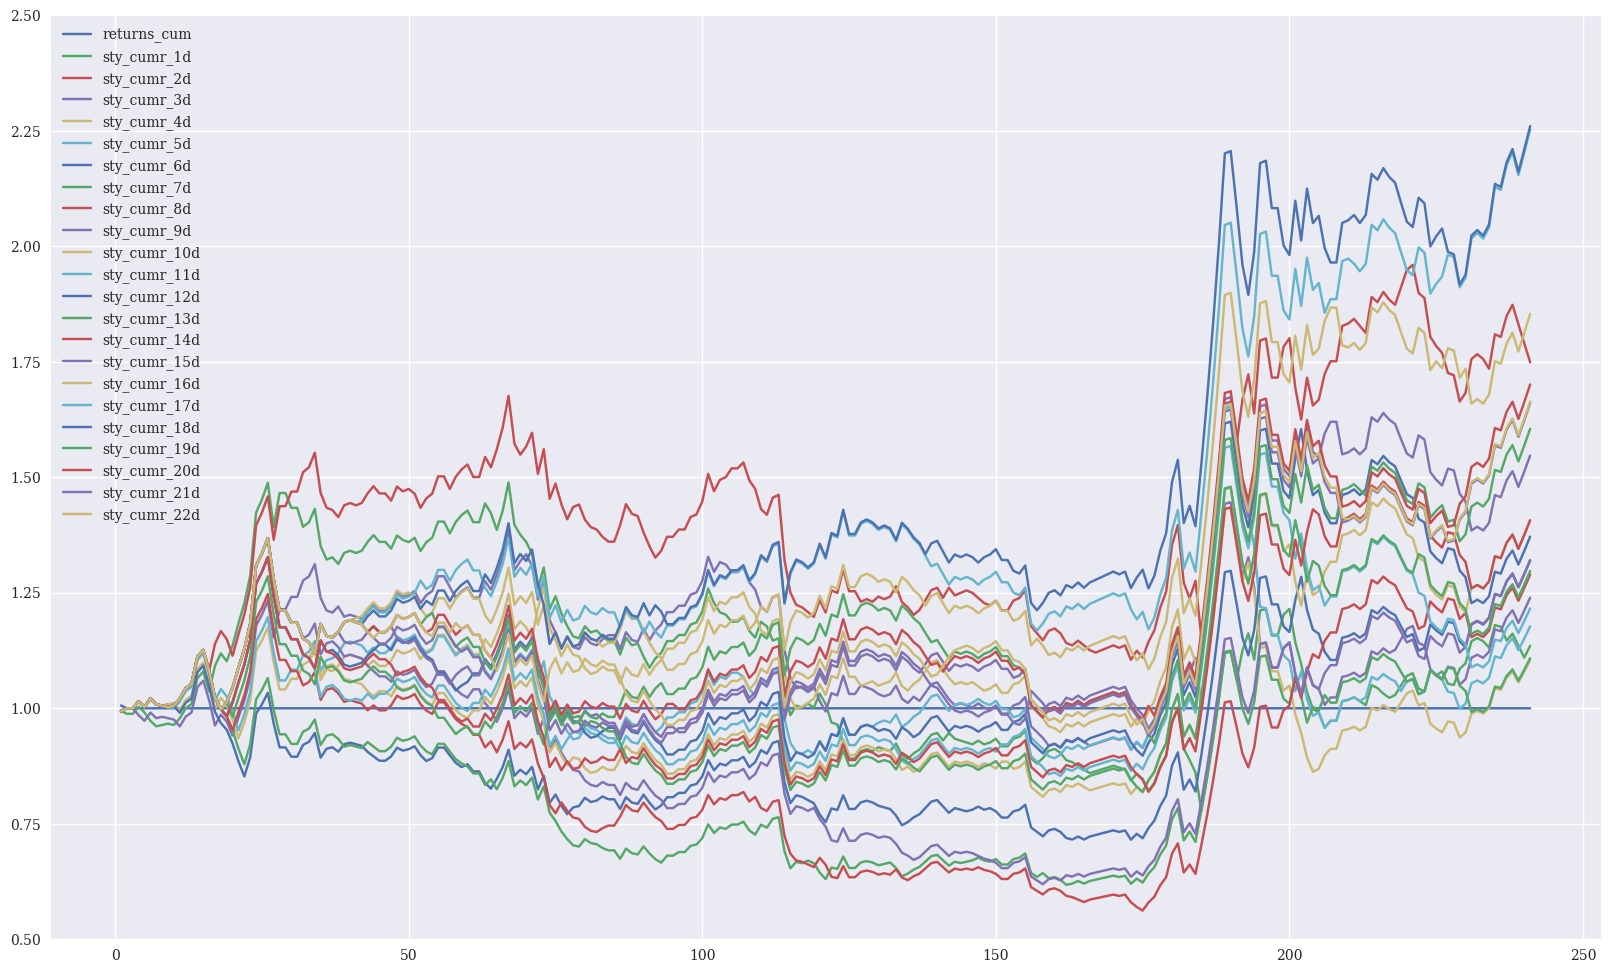

In [75]:
data[price_plot].dropna().plot(ylim=[0.5,2.5],figsize=(20, 12))

In [76]:
mean_returns=[]
std_returns=[]
ratio_mean_std=[]

for days in range(1,23):
    mean_return=data['strategy_%dd'%days].mean()
    std_return=data['strategy_%dd'%days].std()
    mean_returns.append(mean_return)
    std_returns.append(std_return)
    ratio_mean_std.append(mean_return/std_return)
    
print('Mean Returns:',mean_returns)

Mean Returns: [0.0009894741395504803, 0.002781669753591712, 0.001355809585311545, 0.0008785716341678697, 0.001141747132048711, 0.0016120547568273089, 0.0008882432713228551, 0.0015152008426735548, 0.0016160474390533417, 0.0018782241355381395, 0.0012736466777848578, 0.0017715308326327565, 0.0015393659097018187, 0.0018770062905652577, 0.002270852506213369, 0.0030210963420368507, 0.003830539549867243, 0.0038429969777620467, 0.002422942568824992, 0.002663734920095303, 0.0025637182643588677, 0.0025717709946663785]


In [77]:
print('Standard Deviations:',std_returns)

Standard Deviations: [0.03055839480948308, 0.030447146086931203, 0.030544275289124113, 0.03056179849912365, 0.03055306226377106, 0.03053177170222243, 0.030561517768402498, 0.03053675215622874, 0.030531559750315622, 0.030516490739543385, 0.03054782638571803, 0.030522896880659463, 0.030535538490144298, 0.030516565983093547, 0.030489676517907495, 0.03042422685044056, 0.03033256436466056, 0.03033098201684352, 0.030477918565438696, 0.03045773438024949, 0.030466351839884484, 0.030465670309552377]


In [78]:
print('Means/Standard Deviation Ratios:',ratio_mean_std)

Means/Standard Deviation Ratios: [0.03237978125877935, 0.09136060718629012, 0.04438833701169226, 0.02874737997480948, 0.03736931906176101, 0.05279925359555752, 0.029064108597420785, 0.049618925906777925, 0.05293039242898934, 0.06154784151194454, 0.04169352875399094, 0.05803940692651849, 0.05041227323365092, 0.06150778208810048, 0.07447938992988756, 0.09929903418377593, 0.1262847250175153, 0.1267020294835142, 0.07949829525342182, 0.08745676506466019, 0.08414917144765004, 0.08441537535643885]


In [ ]:
x_labels=['stategy_%dd'%days for days in range(1,23)]

plt.figure(figsize=(10,6))
plt.bar(x_labels,mean_returns)
plt.xticks(ratation=45,ha='right')

In [ ]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace = True) 
data.rename(columns={'close': 'price'}, inplace=True) 
data['price'] = list(map(float,data['price']))
data['volume'] = list(map(float,data['volume']))

In [ ]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [ ]:
data.dropna(inplace=True)

In [ ]:
data.head()

In [ ]:
data['returns'].hist(bins=35)

In [ ]:
total_dates = data.index.nunique()
split_index = int(total_dates * 0.7)

In [ ]:
split_date = data.index.unique()[split_index]

In [ ]:
train = data[:split_date]
test = data[split_date:]

In [ ]:
train['position_10'] = np.sign(train['returns'].rolling(10).mean()) 

In [ ]:
train['strategy_10'] = train['position_10'].shift(1) * train['returns']

In [ ]:
train.head(20)

In [ ]:
train.dropna(inplace=True)

In [ ]:
train.head(10)

In [ ]:
train['position_10'].plot(ylim=[-1.1, 1.1], figsize=(16,8),title='Market Positioning')

In [ ]:
buy = train[train['position_10'] == 1]
sell = train[train['position_10'] == -1]
train['price'].plot()
plt.scatter(buy.index, buy['price'], color='blue') 
plt.scatter(sell.index, sell['price'], color='red') 

In [ ]:
train[['returns', 'strategy_10']].cumsum().apply(np.exp).plot(figsize=(10, 6))    

In [ ]:
train[['returns', 'strategy_10']].mean()

In [ ]:
train[['returns', 'strategy_10']].std()

In [ ]:
train[['returns', 'strategy_10']].mean()/ train[['returns', 'strategy_10']].std()

In [ ]:
train['cumret'] =train['strategy_10'].cumsum().apply(np.exp)
train['cummax'] = train['cumret'].cummax()
train[['cumret', 'cummax']].plot(figsize=(10, 6))

In [ ]:
traindrawdown = (train['cummax'] - train['cumret'])
traindrawdown.max()